### Initial set up

In [1]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.feature_selection import RFE
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
pd.set_option("display.float_format", "{:.6f}".format)
np.set_printoptions(suppress=True)

# Data Exploration (Task 1)

## Features



In [2]:
diabetes = sklearn.datasets.load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df["target"] = diabetes.target
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,-0.000000,0.000000,-0.000000,-0.000000,-0.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,152.133484
std,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619,0.047619,77.093005
min,-0.107226,-0.044642,-0.090275,-0.112399,-0.126781,-0.115613,-0.102307,-0.076395,-0.126097,-0.137767,25.000000
25%,-0.037299,-0.044642,-0.034229,-0.036656,-0.034248,-0.030358,-0.035117,-0.039493,-0.033246,-0.033179,87.000000
50%,0.005383,-0.044642,-0.007284,-0.005670,-0.004321,-0.003819,-0.006584,-0.002592,-0.001947,-0.001078,140.500000
75%,0.038076,0.050680,0.031248,0.035644,0.028358,0.029844,0.029312,0.034309,0.032432,0.027917,211.500000
max,0.110727,0.050680,0.170555,0.132044,0.153914,0.198788,0.181179,0.185234,0.133597,0.135612,346.000000


**age:** This feature represents a standardized version of patient age. The youngest person is approximately 0.11 standardized units below the mean age, and the oldest is approximately 0.11 standard deviations above it. The feature varies by about 0.0476 units around its mean of about 0.

**sex:** This feature represents a standardized binary variable of patients' gender. The minimum value of −0.044642 corresponds to the lower of the two original categories after standardization. The feature varies by about 0.0476 units around its mean of about 0.

**bmi:** This feature represents standardized body mass index, a ratio of weight to height used as a general health indicator. The lowest BMI value is approximately 0.10 standard deviations below the mean, while the highest is approximately 0.17 standard deviations above it. The feature varies by about 0.0476 units around its mean of about 0.

**bp:** This feature represents standardized average blood pressure. The lowest blood pressure value is approximately 0.12 standard deviations below the mean, while the highest is approximately 0.13 standard deviations above it. The feature varies by about 0.0476 units around its mean of about 0.

**s1:** This feature represents standardized total cholesterol. The lowest cholesterol value is approximately 0.13 standard deviations below the mean, while the highest is approximately 0.15 standard deviations above it. The feature varies by about 0.0476 units around its mean of about 0.

**s2:** This feature represents standardized low‑density lipoproteins (LDL). The lowest LDL value is approximately 0.12 standard deviations below the mean, while the highest is approximately 0.20 standard deviations above it. The feature varies by about 0.0476 units around its mean of about 0.

**s3:** This feature represents standardized high‑density lipoproteins (HDL). The lowest HDL value is approximately 0.10 standard deviations below the mean, while the highest is approximately 0.18 standard deviations above the mean. The feature varies by about 0.0476 units around its mean of about 0.

**s4:** This feature represents the standardized ratio of total cholesterol to HDL cholesterol. The lowest ratio is approximately 0.08 standard deviations below the mean, while the highest is approximately 0.19 standard deviations above it. The feature varies by about 0.0476 units around its mean of about 0.

**s5:** This feature represents the standardized log‑transformed serum triglyceride level. The lowest value is approximately 0.13 standard deviations below the mean, and the highest is approximately 0.13 standard deviations above it. The feature varies by about 0.0476 units around its mean of about 0.

**s6:** This feature represents the standardized blood sugar level. The lowest value is approximately 0.14 standard deviations below the mean, and the highest is about 0.14 standard deviations above it. The feature varies by about 0.0476 units around its mean of about 0.

**target:** This is a continuous, non‑standardized measure of diabetes disease progression one year after baseline. It ranges from 25 to 346, with a mean of 152. The feature varies by about 77 units around its mean of about 152.




## 80/20 split of dataset

In [3]:
X = df.drop("target", axis=1)
y = df["target"]

# Set random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Linear Regression Model (Task 2)

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred) 
print("R^2 score:", r2)

R^2 score: 0.4526027629719195


# Implement RFE (Task 3)

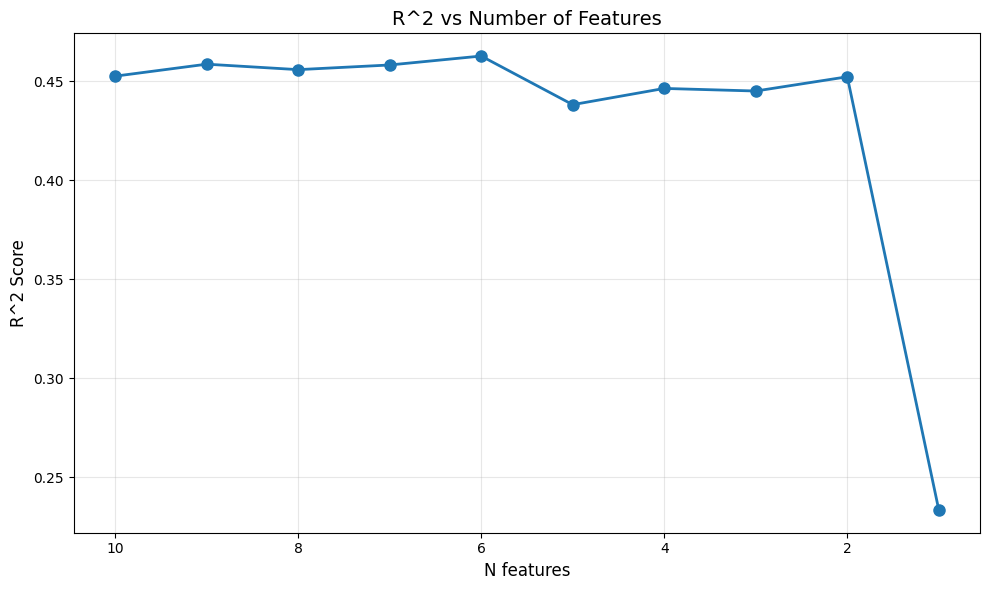


R^2 scores at each iteration:
  10 features: R^2 = 0.4526
  9 features: R^2 = 0.4587
  8 features: R^2 = 0.4559
  7 features: R^2 = 0.4583
  6 features: R^2 = 0.4628
  5 features: R^2 = 0.4382
  4 features: R^2 = 0.4464
  3 features: R^2 = 0.4451
  2 features: R^2 = 0.4523
  1 features: R^2 = 0.2334
Optimal number of features: 6


In [5]:
# RFE elimination
R2_scores = []
Coef = []
feature_sets = []

for n_features in range(10, 0, -1):
    base_model = LinearRegression()
    rfe = RFE(estimator=base_model, n_features_to_select=n_features, step=1)
    rfe.fit(X_train, y_train)
    current_features = X_train.columns[rfe.support_]
    feature_sets.append(list(current_features))
    
    X_train_reduced = X_train[current_features]
    model = LinearRegression()
    model.fit(X_train_reduced, y_train)
    
    Coef.append(dict(zip(current_features, model.coef_)))
    
    X_test_reduced = X_test[current_features]
    y_pred = model.predict(X_test_reduced)
    r2 = r2_score(y_test, y_pred)
    R2_scores.append(r2)

# Plot
num_features = list(range(10, 0, -1))
plt.figure(figsize=(10, 6))
plt.plot(num_features, R2_scores, marker='o', linewidth=2, markersize=8)
plt.xlabel("N features", fontsize=12)
plt.ylabel("R^2 Score", fontsize=12)
plt.title("R^2 vs Number of Features", fontsize=14)
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nR^2 scores at each iteration:")
for i, (nf, r2) in enumerate(zip(num_features, R2_scores)):
    print(f"  {nf} features: R^2 = {r2:.4f}")

threshold = 0.01
threshold_optimal = num_features[0]

for i in range(len(R2_scores) - 1): 
    current_r2 = R2_scores[i]
    next_r2 = R2_scores[i+1]
    if (current_r2 - next_r2) > threshold:
        threshold_optimal = num_features[i]
        break 

print(f"Optimal number of features: {threshold_optimal}")

# Analyze Feature Importance (Task 4)

In [6]:
coef_df = pd.DataFrame(Coef)
coef_df.insert(0, "iteration", range(1, len(Coef) + 1))
coef_df.insert(1, "num_features", [len(fs) for fs in feature_sets])

# replace NaN with 0
coef_df = coef_df.fillna(0)

print("Coefficient Values Across RFE Iterations:")
print(coef_df.round(3))


Coefficient Values Across RFE Iterations:
   iteration  num_features       age         sex        bmi         bp  \
0          1            10 37.904000 -241.964000 542.429000 347.704000   
1          2             9  0.000000 -236.650000 542.800000 354.211000   
2          3             8  0.000000 -233.755000 550.744000 363.792000   
3          4             7  0.000000 -235.364000 551.866000 362.356000   
4          5             6  0.000000 -215.267000 557.314000 350.179000   
5          6             5  0.000000    0.000000 597.893000 306.648000   
6          7             4  0.000000    0.000000 691.460000   0.000000   
7          8             3  0.000000    0.000000 737.686000   0.000000   
8          9             2  0.000000    0.000000 732.109000   0.000000   
9         10             1  0.000000    0.000000 998.578000   0.000000   

           s1         s2         s3         s4         s5        s6  
0 -931.489000 518.062000 163.420000 275.318000 736.199000 48.671000  
1 -

In [7]:
# Statistical test for significant values
selected_features = feature_sets[num_features.index(threshold_optimal)]
X_train_sel = X_train[selected_features]
X_train_sel = sm.add_constant(X_train_sel)
ols_model = sm.OLS(y_train, X_train_sel).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.523
Model:                            OLS   Adj. R-squared:                  0.515
Method:                 Least Squares   F-statistic:                     63.34
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           8.64e-53
Time:                        22:21:39   Log-Likelihood:                -1907.8
No. Observations:                 353   AIC:                             3830.
Df Residuals:                     346   BIC:                             3857.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        151.4226      2.897     52.277      0.0

## Analysis of Top 3 Features

**BMI (Body Mass Index):**
- Highly significant (p ≈ 0.000)
- Coefficient: 557.31

**S1 (Total Cholesterol):**
- significant (p ≈ 0.000)
- Coefficient: -851.52

**S5 (Log of Serum Triglycerides):**
- Highly significant (p ≈ 0.000)
- Coefficient: 803.12

All three features have p-values well below 0.05, confirming their statistical significance at the 95% confidence level. These features also had the greatest difference of coefficient values from 0, indicating their statistical significance to the model.


Task 4.2, 4.3, and 5 is done in the pdf report attached